In [116]:
!pip install missingno

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,mean_squared_error,r2_score,ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB

In [118]:
data=pd.read_csv('iris.csv')
data.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


<Axes: >

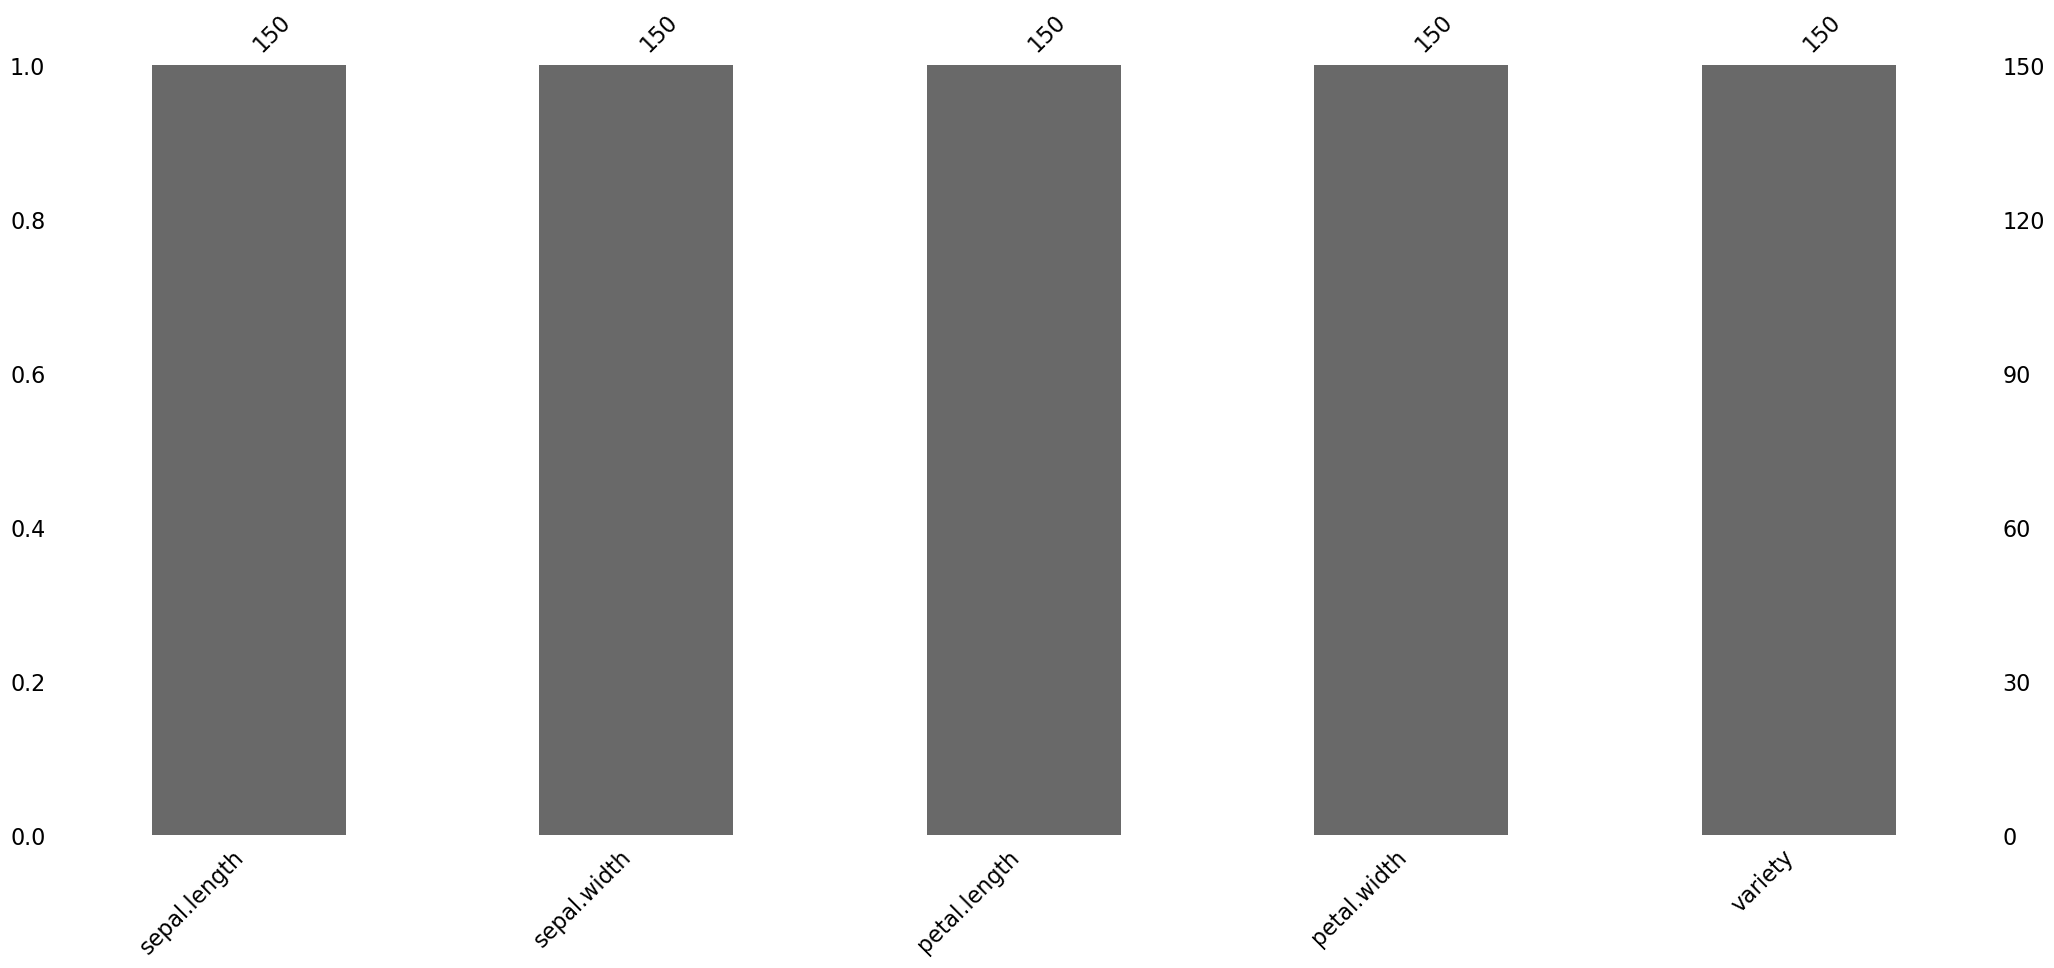

In [119]:
import missingno as msno
msno.bar(data)

In [120]:
scaler=MinMaxScaler()
data['sepal.length']=scaler.fit_transform(data[['sepal.length']])
data['sepal.width']=scaler.fit_transform(data[['sepal.width']])
data['petal.length']=scaler.fit_transform(data[['petal.length']])
data['petal.width']=scaler.fit_transform(data[['petal.width']])

In [121]:
data.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,0.222222,0.625000,0.067797,0.041667,Setosa
1,0.166667,0.416667,0.067797,0.041667,Setosa
2,0.111111,0.500000,0.050847,0.041667,Setosa
3,0.083333,0.458333,0.084746,0.041667,Setosa
4,0.194444,0.666667,0.067797,0.041667,Setosa


In [132]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data['variety'] = le.fit_transform(data[['variety']])

/Users/sanketkakade/miniforge3/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [133]:
data.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,0.222222,0.625000,0.067797,0.041667,0
1,0.166667,0.416667,0.067797,0.041667,0
2,0.111111,0.500000,0.050847,0.041667,0
3,0.083333,0.458333,0.084746,0.041667,0
4,0.194444,0.666667,0.067797,0.041667,0


In [123]:
X=data.drop('variety',axis=1)
y=data['variety']

In [124]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [125]:
model=GaussianNB()

In [126]:
model.fit(X_train,y_train)

GaussianNB()

In [127]:
y_pred=model.predict(X_test)

In [128]:
comp=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})

In [129]:
comp.head(100)

,Actual,Predicted
73,1,1
18,0,0
118,2,2
78,1,1
76,1,1
31,0,0
64,1,1
141,2,2
68,1,1
82,1,1


In [130]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


In [131]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy : ",accuracy)

Accuracy :  0.9777777777777777


In [134]:
mse = mean_squared_error(y_test,y_pred)

In [135]:
mse

0.022222222222222223

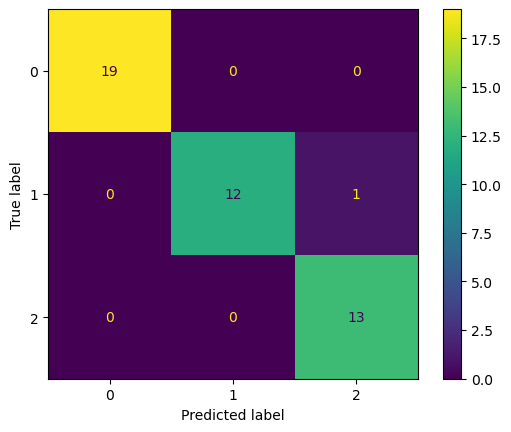

In [147]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.show()